## Experiment No: 7
## Experiment Title: Support Vector Machine Classifiers with Linear and Nonlinear Kernels - Performance Comparison

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Importing Required Libraries


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, 
    confusion_matrix,
    classification_report
)

sns.set_theme(style="whitegrid")
np.random.seed(42)  # For reproducibility

print("All libraries imported successfully!")

All libraries imported successfully!


### Step 2: Load the DataSet

In [2]:
data = load_breast_cancer()
df   = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Shape of Dataset: ", df.shape)
df.head()

Shape of Dataset:  (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Step 3: Exploratory Data Analysis (EDA)

Class Distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


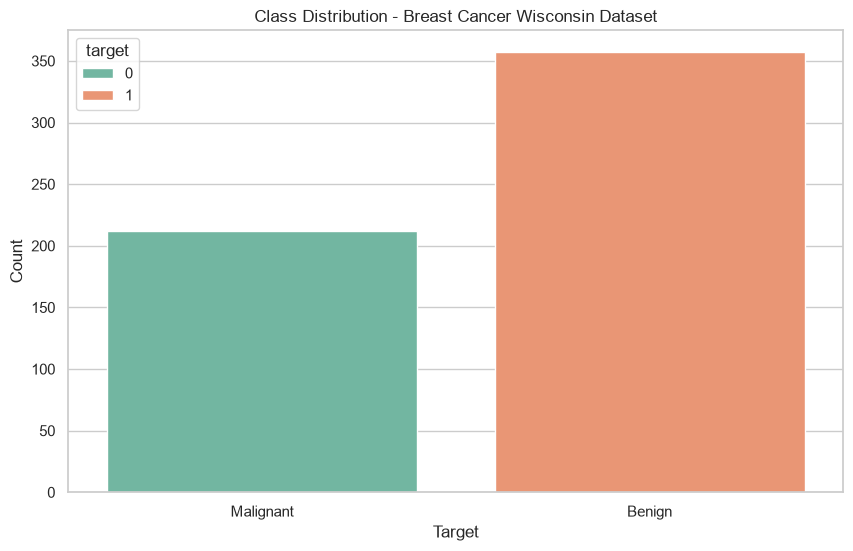

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012


In [3]:
print("Class Distribution:")
print(df["target"].value_counts().rename({0: "Malignant", 1: "Benign"}))

plt.figure(figsize=(10, 6))
sns.countplot(x="target", data=df, palette="Set2", hue="target")
plt.xticks([0, 1], ["Malignant", "Benign"])
plt.title("Class Distribution - Breast Cancer Wisconsin Dataset")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

df.describe().T.head(8)

### Step 4: Split the Dataset into Training and Testing Sets

In [4]:
x = df.drop(columns=["target"])
y = df["target"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=33, stratify=y
)

print(f"Training Set Shape: {x_train.shape}\nTesting Set Shape : {x_test.shape}")

Training Set Shape: (426, 30)
Testing Set Shape : (143, 30)


### Step 5: Feature Scaling (Standardization)
SVMs are distance-based classifiers, so features must be standardized to have zero mean and unit variance before training.

In [5]:
scaler         = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

print("Feature scaling completed. Mean ~0, Std ~1 on training data.")

Feature scaling completed. Mean ~0, Std ~1 on training data.


### Step 6: Train SVM with a Linear Kernel
The linear kernel fits a straight hyperplane decision boundary, assuming the classes are (approximately) linearly separable in feature space.

In [6]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=33)
svm_linear.fit(x_train_scaled, y_train)

y_pred_linear = svm_linear.predict(x_test_scaled)

print("Linear Kernel SVM trained successfully")
print("Number of Support Vectors: ", svm_linear.n_support_.sum())

Linear Kernel SVM trained successfully
Number of Support Vectors:  35


### Step 7: Train SVM with a Nonlinear (RBF) Kernel
The Radial Basis Function (RBF) kernel implicitly maps data into a higher-dimensional space, allowing the model to learn curved, nonlinear decision boundaries.

In [7]:
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=33)
svm_rbf.fit(x_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(x_test_scaled)

print("RBF Kernel SVM trained successfully")
print("Number of Support Vectors: ", svm_rbf.n_support_.sum())

RBF Kernel SVM trained successfully
Number of Support Vectors:  104


### Step 8: Evaluate and Compare the Models 

In [8]:
def get_metrics(y_true, y_pred, model):
    return {
        "Accuracy"        : accuracy_score(y_true, y_pred),
        "Precision"       : precision_score(y_true, y_pred),
        "Recall"          : recall_score(y_true, y_pred),
        "F1-Score"        : f1_score(y_true, y_pred),
        "Support Vectors" : model.n_support_.sum()
    }

comparison_df = pd.DataFrame({
    "Linear Kernel" : get_metrics(y_test, y_pred_linear, svm_linear),
    "RBF Kernel"    : get_metrics(y_test, y_pred_rbf, svm_rbf)
}).T

comparison_df

,Accuracy,Precision,Recall,F1-Score,Support Vectors
Linear Kernel,0.972028,0.988636,0.966667,0.977528,35.0
RBF Kernel,0.972028,0.988636,0.966667,0.977528,104.0


### Step 9: Confusion Matrices 

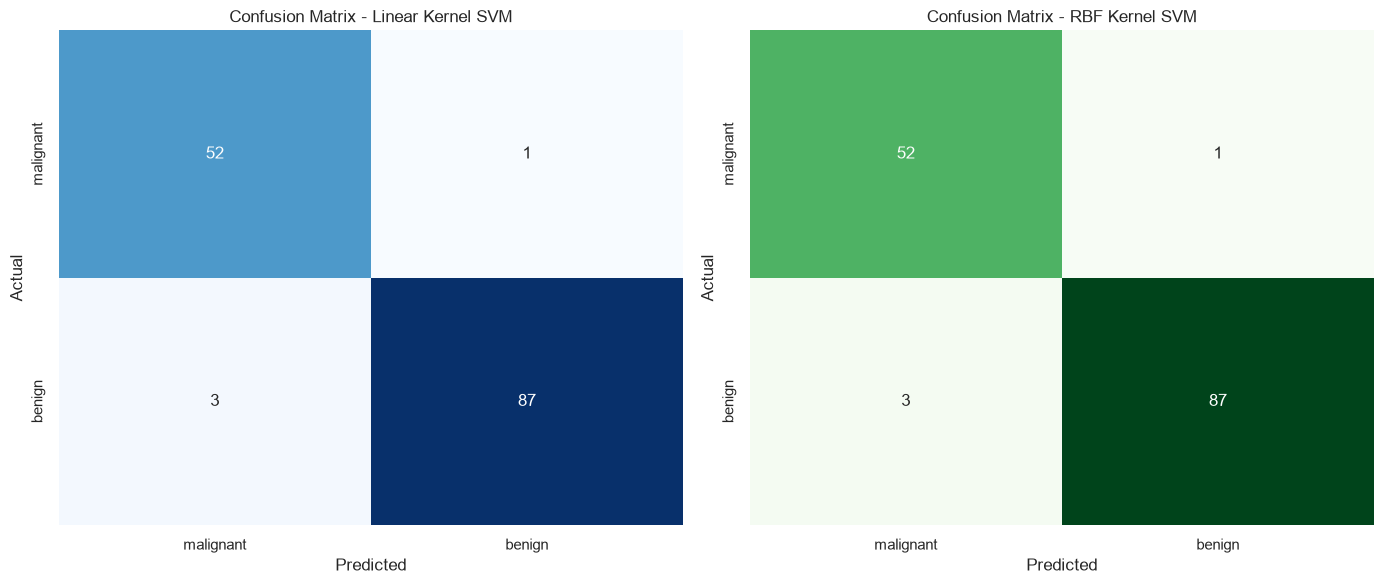

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    confusion_matrix(y_test, y_pred_linear), annot=True, fmt="d",cmap="Blues",xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[0], cbar=False
)
axes[0].set_title("Confusion Matrix - Linear Kernel SVM")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test, y_pred_rbf), annot=True, fmt="d",cmap="Greens",xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[1], cbar=False
)
axes[1].set_title("Confusion Matrix - RBF Kernel SVM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Step 10: Detailed Classification Reports

In [10]:
print("Linear Kernel - Classification Report")
print(classification_report(y_test, y_pred_linear, target_names=data.target_names))

print("RBF Kernel - Classification Report")
print(classification_report(y_test, y_pred_rbf, target_names=data.target_names))

Linear Kernel - Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        53
      benign       0.99      0.97      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143

RBF Kernel - Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        53
      benign       0.99      0.97      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



### Step 11: Decision Boundary Visualization (2D PCA Projection)
To visually contrast how a linear kernel and a nonlinear kernel separate the classes, the 30 features are projected onto their first two principal components, and both kernels are retrained on this 2D projection purely for visualization purposes.

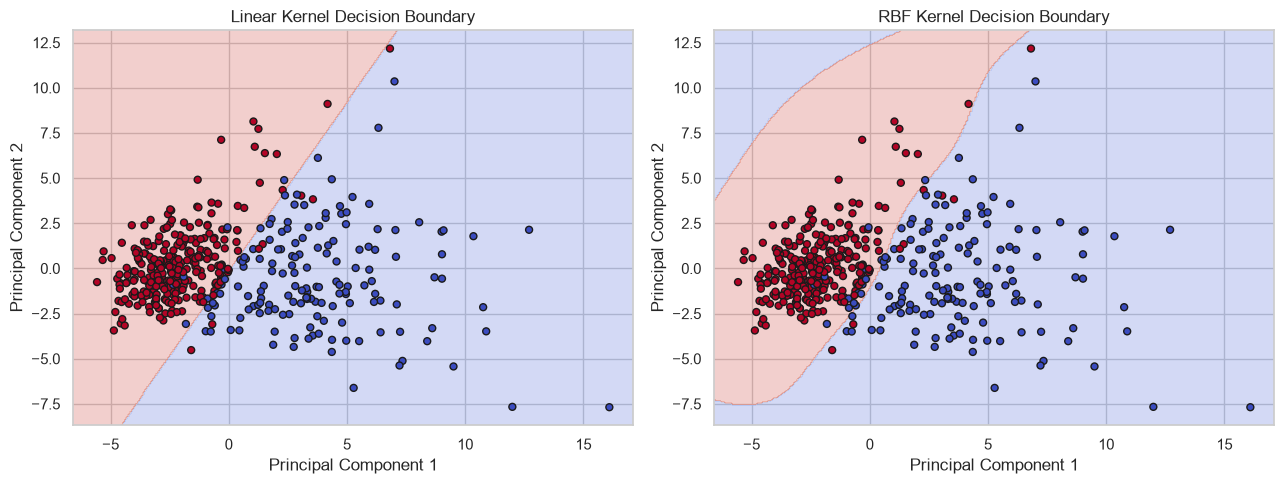

In [11]:
pca         = PCA(n_components=2, random_state=33)
X_train_pca = pca.fit_transform(x_train_scaled)
X_test_pca  = pca.transform(x_test_scaled)

svm_linear_2d = SVC(kernel="linear", C=1.0, random_state=33).fit(X_train_pca, y_train)
svm_rbf_2d    = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=33).fit(X_train_pca, y_train)

def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=25)
    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_decision_boundary(svm_linear_2d, X_train_pca, y_train.values, axes[0], "Linear Kernel Decision Boundary")
plot_decision_boundary(svm_rbf_2d, X_train_pca, y_train.values, axes[1], "RBF Kernel Decision Boundary")
plt.tight_layout()
plt.show()

### Step 12: Bonus - Comparing Additional Kernel Types
As an extension beyond the two required kernels, the polynomial and sigmoid kernels are also benchmarked to observe how kernel choice affects performance on this dataset.

In [12]:
kernel_list   = ["linear", "poly", "rbf", "sigmoid"]
extra_results = []

for k in kernel_list: 
    model = SVC(kernel=k, C=1.0, gamma="scale", random_state=33)
    model.fit(x_train_scaled, y_train)
    preds = model.predict(x_test_scaled)
    extra_results.append({
        "Kernel"          : k,
        "Accuracy"        : accuracy_score(y_test, preds),
        "Precision"       : precision_score(y_test, preds),
        "Recall"          : recall_score(y_test, preds),
        "F1-Score"        : f1_score(y_test, preds),
        "Support Vectors" : model.n_support_.sum()
    })

kernel_comparison_df = pd.DataFrame(extra_results).set_index("Kernel")
kernel_comparison_df

,Accuracy,Precision,Recall,F1-Score,Support Vectors
Kernel,,,,,
linear,0.972028,0.988636,0.966667,0.977528,35
poly,0.916084,0.882353,1.000000,0.937500,145
rbf,0.972028,0.988636,0.966667,0.977528,104
sigmoid,0.958042,0.966667,0.966667,0.966667,68


### Step 13: Final Output

In [13]:
print("Experiment Completed Successfully")
print("\nFinal Linear Vs RBF Kernel SVM Comparison:")
print(comparison_df)
print("-" * 70)
print("\nKernel Comparison Across Different SVM Kernels:")
print(kernel_comparison_df)

Experiment Completed Successfully

Final Linear Vs RBF Kernel SVM Comparison:
               Accuracy  Precision    Recall  F1-Score  Support Vectors
Linear Kernel  0.972028   0.988636  0.966667  0.977528             35.0
RBF Kernel     0.972028   0.988636  0.966667  0.977528            104.0
----------------------------------------------------------------------

Kernel Comparison Across Different SVM Kernels:
         Accuracy  Precision    Recall  F1-Score  Support Vectors
Kernel                                                           
linear   0.972028   0.988636  0.966667  0.977528               35
poly     0.916084   0.882353  1.000000  0.937500              145
rbf      0.972028   0.988636  0.966667  0.977528              104
sigmoid  0.958042   0.966667  0.966667  0.966667               68
